**Load Data**

The data loading steps are applicable only to Google Colab and Google Drive. Please adapt accordingly.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
# Change to your folder location
path = "/content/drive/MyDrive/Fall 36490 - Armada Project/Data_CSV"
print(os.listdir(path))

['CMU_ARMADA_LOADS_202403-202502_1.xlsx - Sheet1.csv', 'CMU_ARMADA_LOADS_202403-202502_2.xlsx - Sheet1.csv', 'CMU_ARMADA_LOADS_202403-202502_3.xlsx - Sheet1.csv', 'CMU_ARMADA_LOADS_202403-202502_4.xlsx - Sheet1.csv', 'CMU_ARMADA_LOADS_202403-202502_5.xlsx - Sheet1.csv', 'CMU_ARMADA_LOADS_202403-202502_5.xlsx - Sheet1 (1).gsheet', 'CMU_ARMADA_LOADS_202403-202502_5.xlsx - Sheet1.gsheet']


In [ ]:
import pandas as pd
import numpy as np
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, classification_report, confusion_matrix,
                              accuracy_score)
from sklearn.ensemble import GradientBoostingClassifier
import lightgbm as lgb

warnings.filterwarnings('ignore')


# Change these to your own folder and file names
base = "/content/drive/MyDrive/Fall 36490 - Armada Project/Data_CSV"

files = [
    f"{base}/CMU_ARMADA_LOADS_202403-202502_1.xlsx - Sheet1.csv",
    f"{base}/CMU_ARMADA_LOADS_202403-202502_2.xlsx - Sheet1.csv",
    f"{base}/CMU_ARMADA_LOADS_202403-202502_3.xlsx - Sheet1.csv",
    f"{base}/CMU_ARMADA_LOADS_202403-202502_4.xlsx - Sheet1.csv",
    f"{base}/CMU_ARMADA_LOADS_202403-202502_5.xlsx - Sheet1.csv",
]

dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)

print(f"Total records before filtering: {len(df):,}")

# Exclude March and April data (biased months)
excluded_months = ['MAR_2024', 'APR_2024', 'MAR_2025', 'APR_2025']
df = df[~df['TIME_PERIOD'].isin(excluded_months)]
print(f"Records after excluding March/April: {len(df):,}")

# add "carrier_accepted" column
df['carrier_accepted'] = (df['AWARD_TYPE'].str.upper().str.strip() == 'PRIMARY').astype(int)
print(f"PRIMARY acceptance rate: {df['carrier_accepted'].mean():.2%}")

Total records before filtering: 460,951
Records after excluding March/April: 384,873
PRIMARY acceptance rate: 90.62%


In [ ]:
df['PAID_LINEHAUL'].abs()

,PAID_LINEHAUL
1,1215.0
2,4053.0
3,410.0
4,1665.0
5,985.0
...,...
460946,1320.0
460947,1320.0
460948,821.0
460949,1900.0


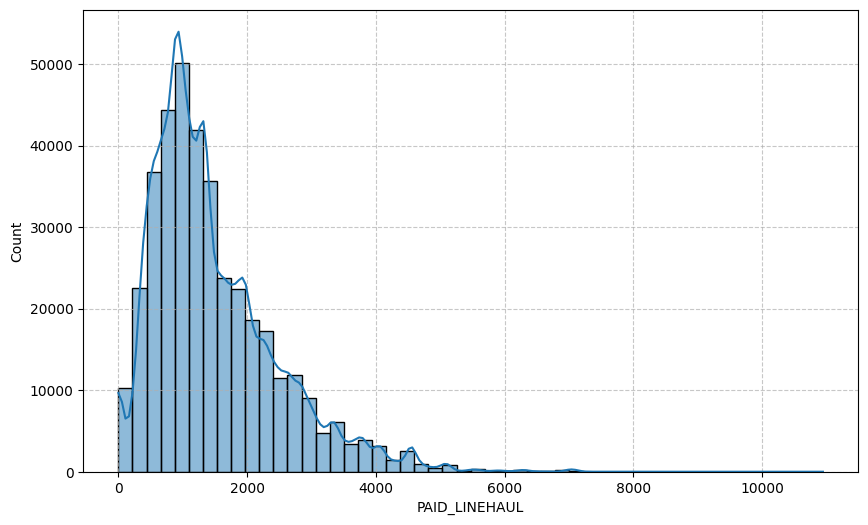

In [ ]:
# Check data is loaded correctly

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['PAID_LINEHAUL'].abs(), bins=50, kde=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Preprocess Data & Feature Engineering for Causal Analysis**

In [ ]:
print(df.columns)

Index(['TIME_PERIOD', 'LOAD_ID', 'TRANSPORTATION_MODE', 'LANE',
       'TEMPERATURE_REQ', 'TEMPERATURE_ZONE', 'LOAD_LEAD_TIME',
       'NUMBER_OF_STOPS', 'CUSTOMER_SKEY', 'CARRIER_SKEY', 'CARRIER_CLASS_CD',
       'AWARD_TYPE', 'DATE_CREATED', 'DATE_CHANGED', 'PICK_DUE_DATE',
       'PICK_DEPARTURE_DATE', 'PICK_ACTUAL_DATE', 'PICK_APPT_DATE',
       'DROP_DUE_DATE', 'DROP_DEPARTURE_DATE', 'DROP_ACTUAL_DATE',
       'DROP_APPT_DATE', 'ORIGINID', 'ORIGINCITY', 'ORIGINSTATE',
       'ORIGIN_COUNTRY', 'ORIGINZIP', 'ORIGIN_REGION', 'ORIGINLOCATIONTYPE',
       'DESTINATIONID', 'DESTINATIONCITY', 'DESTINATIONSTATE',
       'DESTINATION_COUNTRY', 'DESTINATIONZIP', 'DESTINATION_REGION',
       'DESTINATIONLOCATIONTYPE', 'CONTRACT_LINEHAUL', 'SPOT_LINEHAUL',
       'PAID_LINEHAUL', 'NAP_LINEHAUL', 'MILEAGE', 'CUBE', 'WEIGHT', 'PIECES',
       'QUANTITY', 'TRANSIT_TIME', 'TRANSIT_TIME_STANDARD',
       'carrier_accepted'],
      dtype='object')


In [ ]:
# Parse dates
df['PICK_DUE_DATE'] = pd.to_datetime(df['PICK_DUE_DATE'], errors='coerce')
df['LANE_ID'] = (df['ORIGINID'].astype(str) + '_' +
                 df['DESTINATIONID'].astype(str) + '_' +
                 df['TEMPERATURE_ZONE'].astype(str))

print(f"Unique lanes: {df['LANE_ID'].nunique():,}")
print(f"Unique carriers: {df['CARRIER_SKEY'].nunique():,}")
print(f"Date range: {df['PICK_DUE_DATE'].min()} to {df['PICK_DUE_DATE'].max()}")
print()

print("FEATURE ENGINEERING")

# Price Premium
print("Premium Features")
valid_paid = df['PAID_LINEHAUL'].abs() > 50
valid_spot = df['SPOT_LINEHAUL'].abs() > 50
valid_premium_calc = valid_paid & valid_spot

df['premium_pct'] = np.nan
df.loc[valid_premium_calc, 'premium_pct'] = (
    (df.loc[valid_premium_calc, 'PAID_LINEHAUL'] - df.loc[valid_premium_calc, 'NAP_LINEHAUL']) /
    df.loc[valid_premium_calc, 'SPOT_LINEHAUL'].abs()
) * 100


df['premium_pct'] = df['premium_pct'].clip(-100, 200)


df['is_underpaid'] = (df['premium_pct'] < -5).astype(int)
df['is_overpaid'] = (df['premium_pct'] > 5).astype(int)
df['premium_pct'].fillna(df['premium_pct'].median(), inplace=True)

# GEOGRAPHY FEATURES
print("Geography Features")

# Origin location-level metrics
# Create a new df that aggregates counts of origins/destinations
# TODO: MORE AGGREGATION
origin_as_origin = df.groupby('ORIGINID').size().reset_index(name='as_origin')
origin_as_origin.columns = ['LOCATION', 'as_origin']

origin_as_dest = df.groupby('DESTINATIONID').size().reset_index(name='as_dest')
origin_as_dest.columns = ['LOCATION', 'as_dest']

# outbound ratio = times appears as ORIGIN/ (times appears as DESTINATION + 1)
origin_location_flow = origin_as_origin.merge(origin_as_dest, on='LOCATION', how='outer').fillna(0)
origin_location_flow['location_outbound_ratio'] = origin_location_flow['as_origin'] / (origin_location_flow['as_dest'] + 1)

df = df.merge(
    origin_location_flow[['LOCATION', 'location_outbound_ratio']].rename(
        columns={'LOCATION': 'ORIGINID', 'location_outbound_ratio': 'origin_outbound_ratio'}
    ),
    on='ORIGINID',
    how='left'
)

# Destination location-level
df = df.merge(
    origin_location_flow[['LOCATION', 'location_outbound_ratio']].rename(
        columns={'LOCATION': 'DESTINATIONID', 'location_outbound_ratio': 'destination_outbound_ratio'}
    ),
    on='DESTINATIONID',
    how='left'
)

print(f"   Origin outbound ratio - mean: {df['origin_outbound_ratio'].mean():.2f}")
print(f"   Destination outbound ratio - mean: {df['destination_outbound_ratio'].mean():.2f}")

# Dest region-level metrics
dest_region_as_origin = df.groupby('ORIGIN_REGION').size().reset_index(name='as_origin')
dest_region_as_origin.columns = ['REGION', 'as_origin']

dest_region_as_dest = df.groupby('DESTINATION_REGION').size().reset_index(name='as_dest')
dest_region_as_dest.columns = ['REGION', 'as_dest']

dest_region_flow = dest_region_as_origin.merge(dest_region_as_dest, on='REGION', how='outer').fillna(0)
dest_region_flow['destination_region_outbound_ratio'] = dest_region_flow['as_origin'] / (dest_region_flow['as_dest'] + 1)
dest_region_flow['destination_region_is_freight_sink'] = (dest_region_flow['destination_region_outbound_ratio'] < 0.5).astype(int)
dest_region_flow['destination_region_backhaul_difficulty'] = 1 / (dest_region_flow['destination_region_outbound_ratio'] + 0.1)
dest_region_flow['destination_region_total_volume'] = dest_region_flow['as_origin'] + dest_region_flow['as_dest']
dest_region_flow['destination_region_log_volume'] = np.log1p(dest_region_flow['destination_region_total_volume'])

# Historical acceptance by destination region
dest_region_acceptance = df.groupby('DESTINATION_REGION')['carrier_accepted'].mean().reset_index()
dest_region_acceptance.columns = ['REGION', 'destination_region_historical_acceptance']
dest_region_flow = dest_region_flow.merge(dest_region_acceptance, on='REGION', how='left')

#merge to main dataframe
df = df.merge(
    dest_region_flow[['REGION', 'destination_region_outbound_ratio', 'destination_region_is_freight_sink',
                      'destination_region_backhaul_difficulty', 'destination_region_log_volume',
                      'destination_region_historical_acceptance']].rename(
        columns={'REGION': 'DESTINATION_REGION'}
    ),
    on='DESTINATION_REGION',
    how='left'
)

# Fill missing values
df['origin_outbound_ratio'].fillna(df['origin_outbound_ratio'].median(), inplace=True)
df['destination_outbound_ratio'].fillna(df['destination_outbound_ratio'].median(), inplace=True)
df['destination_region_outbound_ratio'].fillna(df['destination_region_outbound_ratio'].median(), inplace=True)
# destination_region_backhaul_difficulty = 1 / (destination_region_outbound_ratio + 0.1)
df['destination_region_backhaul_difficulty'].fillna(df['destination_region_backhaul_difficulty'].median(), inplace=True)
# destination_region_is_freight_sink = 1 if destination_region_outbound_ratio < 0.5 else 0
df['destination_region_is_freight_sink'].fillna(0, inplace=True)
df['destination_region_log_volume'].fillna(df['destination_region_log_volume'].median(), inplace=True)
# Total Loads accepted / Total loads to region
df['destination_region_historical_acceptance'].fillna(df['carrier_accepted'].mean(), inplace=True)

print(f"   Freight sink regions: {df['destination_region_is_freight_sink'].sum():,} loads ({df['destination_region_is_freight_sink'].mean():.1%})")
print()

# Time
print("Time Features")
df['day_of_week'] = df['PICK_DUE_DATE'].dt.dayofweek
df['month'] = df['PICK_DUE_DATE'].dt.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['quarter'] = df['PICK_DUE_DATE'].dt.quarter
print()

# Lead time
print("Lead Time Features")
df['lead_time_hours'] = df['LOAD_LEAD_TIME'] / 60
df['is_short_notice'] = (df['lead_time_hours'] < 24).astype(int)
print()

# Distance
print("Distance Features")
df['distance'] = df['MILEAGE']
df['is_short_haul'] = (df['distance'] < 250).astype(int)
df['is_long_haul'] = (df['distance'] > 1000).astype(int)
print()

# Operational
print("Operational Features")
df['is_temp_controlled'] = (df['TEMPERATURE_ZONE'] == 'TEMP CONTROLLED').astype(int)
df['is_supplier_origin'] = (df['ORIGINLOCATIONTYPE'] == 'SUPPLIER').astype(int)
df['is_distributor_dest'] = (df['DESTINATIONLOCATIONTYPE'] == 'DISTRIBUTOR').astype(int)
print()

# Interaction
print("Interaction Features")
df['premium_x_leadtime'] = df['premium_pct'] * np.log1p(df['lead_time_hours'])
df['premium_x_distance'] = df['premium_pct'] * np.log1p(df['distance'])
df['leadtime_x_dest_region_backhaul'] = df['lead_time_hours'] * df['destination_region_backhaul_difficulty']
df['distance_x_dest_region_backhaul'] = df['distance'] * df['destination_region_backhaul_difficulty']
df['premium_x_dest_region_backhaul'] = df['premium_pct'] * df['destination_region_backhaul_difficulty']
print()


# Calculate destination-level freight sink stats
total_destinations = len(df)
freight_sink_destinations = (df['destination_region_outbound_ratio'] < 0.5).sum()
freight_sink_pct = freight_sink_destinations / total_destinations * 100

print(f"Destinations with low outbound ratio (<0.5): {freight_sink_destinations:,} ({freight_sink_pct:.1f}%)")
print(f"Destinations with good backhaul (>=0.5): {total_destinations - freight_sink_destinations:,} ({100-freight_sink_pct:.1f}%)")
print()

print("Distribution of outbound ratios:")
print(f"  Mean: {df['destination_region_outbound_ratio'].mean():.2f}")
print(f"  Median: {df['destination_region_outbound_ratio'].median():.2f}")
print(f"  25th percentile: {df['destination_region_outbound_ratio'].quantile(0.25):.2f}")
print(f"  75th percentile: {df['destination_region_outbound_ratio'].quantile(0.75):.2f}")
print()

# Calculate acceptance rates by freight sink status
freight_sink_mask = df['destination_region_is_freight_sink'] == 1
freight_sink_acceptance = df[freight_sink_mask]['carrier_accepted'].mean()
good_backhaul_acceptance = df[~freight_sink_mask]['carrier_accepted'].mean()

print("Acceptance rates by destination type:")
print(f"  Freight sink destinations (<0.5 outbound): {freight_sink_acceptance:.2%}")
print(f"  Good backhaul destinations (>=0.5 outbound): {good_backhaul_acceptance:.2%}")

# Calculate premium by freight sink status
freight_sink_premium = df[freight_sink_mask]['premium_pct'].median()
good_backhaul_premium = df[~freight_sink_mask]['premium_pct'].median()

print("Premium rates by destination type:")
print(f"  Freight sink destinations: {freight_sink_premium:.1f}% median premium")
print(f"  Good backhaul destinations: {good_backhaul_premium:.1f}% median premium")




Unique lanes: 10,956
Unique carriers: 226
Date range: 2012-12-12 00:00:00 to 2025-02-28 00:00:00

FEATURE ENGINEERING
Premium Features
Geography Features
   Origin outbound ratio - mean: 1274.62
   Destination outbound ratio - mean: 0.15
   Freight sink regions: 179,835.0 loads (46.7%)

Time Features

Lead Time Features

Distance Features

Operational Features

Interaction Features

Destinations with low outbound ratio (<0.5): 179,835 (46.7%)
Destinations with good backhaul (>=0.5): 205,038 (53.3%)

Distribution of outbound ratios:
  Mean: 0.82
  Median: 0.52
  25th percentile: 0.25
  75th percentile: 0.92

Acceptance rates by destination type:
  Freight sink destinations (<0.5 outbound): 91.71%
  Good backhaul destinations (>=0.5 outbound): 89.66%
Premium rates by destination type:
  Freight sink destinations: -1.2% median premium
  Good backhaul destinations: -1.2% median premium


In [ ]:
print("Adding Extra Origin Features")

# 1. Basic Aggregations
origin_stats = df.groupby('ORIGIN_REGION').agg(
    origin_total_loads=('LOAD_ID', 'count'),
    origin_outbound_unique_dest_regions=('DESTINATION_REGION', 'nunique'),
    origin_num_active_carriers=('CARRIER_SKEY', 'nunique')
).reset_index()

# 2. Derived Ratio Features
origin_stats['origin_carriers_per_100_loads'] = (
    origin_stats['origin_num_active_carriers'] / origin_stats['origin_total_loads']
)

origin_stats['origin_unique_dest_regions_per_100_loads'] = (
    origin_stats['origin_outbound_unique_dest_regions'] / origin_stats['origin_total_loads']
)

# 3. Rare Origin Indicator (Threshold <= 5 loads)
origin_stats['is_rare_origin'] = (origin_stats['origin_total_loads'] <= 5).astype(int)

# 4. Top-3 Destination Concentration
# Count loads per origin-destination pair
od_counts = df.groupby(['ORIGIN_REGION', 'DESTINATION_REGION']).size().reset_index(name='pair_count')
# Sort descending by count within each origin
od_counts = od_counts.sort_values(['ORIGIN_REGION', 'pair_count'], ascending=[True, False])
# Sum the counts of the top 3 destinations for each origin
top3_sum = od_counts.groupby('ORIGIN_REGION').head(3).groupby('ORIGIN_REGION')['pair_count'].sum().reset_index(name='top3_loads')

# Merge top3 sums back to stats
origin_stats = origin_stats.merge(top3_sum, on='ORIGIN_REGION', how='left')
origin_stats['origin_popular_dest_proportion'] = (origin_stats['top3_loads'] / origin_stats['origin_total_loads']) * 100
# Fill NaN with 0 (though technically shouldn't happen if totals exist)
origin_stats['origin_popular_dest_proportion'].fillna(0, inplace=True)


# 5. Merge back to main DataFrame
cols_to_add = ['origin_total_loads', 'origin_outbound_unique_dest_regions',
               'origin_num_active_carriers', 'origin_carriers_per_100_loads',
               'origin_unique_dest_regions_per_100_loads', 'origin_popular_dest_proportion',
               'is_rare_origin']

# Clean up existing columns if re-running
df = df.drop(columns=[c for c in cols_to_add if c in df.columns], errors='ignore')

# Merge on ORIGIN_REGION
df = df.merge(origin_stats[['ORIGIN_REGION'] + cols_to_add], on='ORIGIN_REGION', how='left')

# Display the new features
print(df[cols_to_add].describe())
display(df[['ORIGIN_REGION'] + cols_to_add].head())

Adding Extra Origin Features
       origin_total_loads  origin_outbound_unique_dest_regions  \
count       383933.000000                        383933.000000   
mean          7979.704680                            38.071700   
std           6798.709375                            14.184101   
min              1.000000                             1.000000   
25%           3391.000000                            27.000000   
50%           6473.000000                            39.000000   
75%           9542.000000                            49.000000   
max          27823.000000                            62.000000   

       origin_num_active_carriers  origin_carriers_per_100_loads  \
count               383933.000000                  383933.000000   
mean                    54.412627                       0.010976   
std                     24.676569                       0.011447   
min                      1.000000                       0.001048   
25%                     36.000000   

,ORIGIN_REGION,origin_total_loads,origin_outbound_unique_dest_regions,origin_num_active_carriers,origin_carriers_per_100_loads,origin_unique_dest_regions_per_100_loads,origin_popular_dest_proportion,is_rare_origin
0,WI_GRE,2860.0,41.0,49.0,0.017133,0.014336,54.055944,0.0
1,AR_FAY,4657.0,44.0,41.0,0.008804,0.009448,22.095770,0.0
2,CA_STK,9471.0,26.0,51.0,0.005385,0.002745,74.733397,0.0
3,NC_CHA,7325.0,51.0,73.0,0.009966,0.006962,31.440273,0.0
4,CA_ONT,8263.0,41.0,66.0,0.007987,0.004962,63.669369,0.0


In [ ]:
print("Adding Extra Destination Features")

# Group by DESTINATION_REGION to calculate counts
dest_stats = df.groupby('DESTINATION_REGION').agg(
    destination_total_loads=('LOAD_ID', 'count')
).reset_index()

# Rare Destination Indicator (Threshold <= 5 loads)
dest_stats['is_rare_destination'] = (dest_stats['destination_total_loads'] <= 5).astype(int)

# Merge back into the main dataframe
cols_to_add_dest = ['destination_total_loads', 'is_rare_destination']
df = df.drop(columns=[c for c in cols_to_add_dest if c in df.columns], errors='ignore')

# Merge on DESTINATION_REGION
df = df.merge(dest_stats, on='DESTINATION_REGION', how='left')

# Handle potential missing values (though unlikely if built from same df)
df['is_rare_destination'].fillna(0, inplace=True)

# Display the new features
print(df[cols_to_add_dest].describe())
display(df[['DESTINATION_REGION'] + cols_to_add_dest].head())

Adding Extra Destination Features
       destination_total_loads  is_rare_destination
count            384752.000000        384873.000000
mean              11477.962989             0.000073
std                6370.032092             0.008529
min                   1.000000             0.000000
25%                6405.000000             0.000000
50%               10491.000000             0.000000
75%               15372.000000             0.000000
max               25547.000000             1.000000


,DESTINATION_REGION,destination_total_loads,is_rare_destination
0,MO_STL,7849.0,0.0
1,MD_BAL,3739.0,0.0
2,CA_STK,13004.0,0.0
3,TX_HOU,13498.0,0.0
4,CA_STK,13004.0,0.0


In [ ]:
pd.set_option('display.max_rows', None)
print(df.dtypes)

TIME_PERIOD                                         object
LOAD_ID                                              int64
TRANSPORTATION_MODE                                 object
LANE                                                object
TEMPERATURE_REQ                                     object
TEMPERATURE_ZONE                                    object
LOAD_LEAD_TIME                                       int64
NUMBER_OF_STOPS                                      int64
CUSTOMER_SKEY                                        int64
CARRIER_SKEY                                         int64
CARRIER_CLASS_CD                                    object
AWARD_TYPE                                          object
DATE_CREATED                                        object
DATE_CHANGED                                        object
PICK_DUE_DATE                               datetime64[ns]
PICK_DEPARTURE_DATE                                 object
PICK_ACTUAL_DATE                                    obje

In [ ]:
cols_to_categorical = ['month', 'day_of_week', 'quarter', 'DESTINATION_REGION',
                       'ORIGIN_REGION', 'CARRIER_CLASS_CD']
df[cols_to_categorical] = df[cols_to_categorical].astype('category')

In [ ]:
print("Original 'carrier_accepted' distribution:")
display(df['carrier_accepted'].value_counts(normalize=True))

Original 'carrier_accepted' distribution:


,proportion
carrier_accepted,
1,0.9062
0,0.0938


Split data

In [ ]:
from sklearn.model_selection import train_test_split

print("TRAIN/TEST SPLIT")

# Assuming 'carrier_accepted' is your target variable (y)
X = df.drop('carrier_accepted', axis=1) # All other features
y = df['carrier_accepted'] # Target variable

# Perform a stratified split
X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X,
    y,
    test_size=0.2, # 20% for testing
    random_state=42, # for reproducibility
    stratify=y # Stratify on the target variable
)

# Recombine to get the train/test DataFrames if needed for later feature engineering
df_train = pd.concat([X_train_strat, y_train_strat], axis=1)
df_test = pd.concat([X_test_strat, y_test_strat], axis=1)

print(f"\nTotal records: {len(df):,}")
print(f"Stratified Training set: {len(df_train):,} records")
print(f"Stratified Test set: {len(df_test):,} records")


TRAIN/TEST SPLIT

Total records: 384,873
Stratified Training set: 307,898 records
Stratified Test set: 76,975 records


**Define Training variables (crucial)** and train logistic model

In [ ]:
pd.set_option('display.max_rows', None)
print(df.dtypes)

TIME_PERIOD                                         object
LOAD_ID                                              int64
TRANSPORTATION_MODE                                 object
LANE                                                object
TEMPERATURE_REQ                                     object
TEMPERATURE_ZONE                                    object
LOAD_LEAD_TIME                                       int64
NUMBER_OF_STOPS                                      int64
CUSTOMER_SKEY                                        int64
CARRIER_SKEY                                         int64
CARRIER_CLASS_CD                                  category
AWARD_TYPE                                          object
DATE_CREATED                                        object
DATE_CHANGED                                        object
PICK_DUE_DATE                               datetime64[ns]
PICK_DEPARTURE_DATE                                 object
PICK_ACTUAL_DATE                                    obje

In [ ]:
# Define feature sets for causal model ONLY
print("FEATURE SETS")

# For Logistic Regression, only key features, did not include catagorical (high-cardinality problem)
logistic_features = [
    'CUBE',
    'WEIGHT',
    'PIECES',
    'QUANTITY',
    'origin_total_loads',
    'origin_outbound_ratio',
    'origin_outbound_unique_dest_regions',
    'origin_num_active_carriers',
    'origin_popular_dest_proportion',
    'lead_time_hours',
    'is_temp_controlled',
    'is_supplier_origin',
    'is_rare_origin'
]

# For tree models, more features including binary indicators and interactions
tree_continuous_features = [
    'CUBE',
    'WEIGHT',
    'PIECES',
    'QUANTITY',
    'origin_total_loads',
    'origin_outbound_ratio',
    'origin_outbound_unique_dest_regions',
    'origin_unique_dest_regions_per_100_loads',
    'origin_num_active_carriers',
    'origin_popular_dest_proportion',
    'lead_time_hours'
]

tree_binary_features = [
    'is_weekend',
    'is_short_notice',
    'is_temp_controlled',
    'is_supplier_origin',
    'is_rare_origin'
]

tree_categorical_features = [
    'month',
    'day_of_week',
    'quarter',
    'ORIGIN_REGION',
    'DESTINATION_REGION']

tree_features = tree_continuous_features + tree_binary_features + tree_categorical_features

print(f"Logistic features: {len(logistic_features)}")

print("Logistic Regression features:")
for f in logistic_features:
    print(f"  - {f}")
print()

print(f"Tree model features: {len(tree_features)}")
print(f"  Continuous: {len(tree_continuous_features)}")
print(f"  Binary: {len(tree_binary_features)}")
print(f"  Categorical: {len(tree_categorical_features)}")

# Prepare/Clean data
df_train_clean = df_train.dropna(subset=logistic_features + tree_features + ['carrier_accepted'])
df_test_clean = df_test.dropna(subset=logistic_features + tree_features + ['carrier_accepted'])

print(f"After removing missing values:")
print(f"  Training: {len(df_train_clean):,} loads")
print(f"  Test: {len(df_test_clean):,} loads")
print()

# Clean infinite values
for feat in logistic_features + tree_continuous_features + tree_binary_features:
    if feat in df_train_clean.columns:
        inf_mask_train = np.isinf(df_train_clean[feat])
        inf_mask_test = np.isinf(df_test_clean[feat])
        if inf_mask_train.any() or inf_mask_test.any():
            median_val = df_train_clean.loc[~inf_mask_train, feat].median()
            df_train_clean.loc[inf_mask_train, feat] = median_val
            df_test_clean.loc[inf_mask_test, feat] = median_val

# Extract features and target
X_train_logistic = df_train_clean[logistic_features]
X_test_logistic = df_test_clean[logistic_features]
X_train_tree = df_train_clean[tree_features]
X_test_tree = df_test_clean[tree_features]
y_train = df_train_clean['carrier_accepted']
y_test = df_test_clean['carrier_accepted']

# scale features for logistic regression
scaler_logistic = StandardScaler()
X_train_logistic_scaled = scaler_logistic.fit_transform(X_train_logistic)
X_test_logistic_scaled = scaler_logistic.transform(X_test_logistic)

# calculate class weights
neg_weight = len(y_train) / (2 * (y_train == 0).sum())
pos_weight = len(y_train) / (2 * (y_train == 1).sum())
sample_weights = np.where(y_train == 0, neg_weight, pos_weight)

print("MODEL 1: LOGISTIC REGRESSION")

# simple logistic regression with key features
logistic_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

logistic_model.fit(X_train_logistic_scaled, y_train)
print()

y_train_proba_lr = logistic_model.predict_proba(X_train_logistic_scaled)[:, 1]
y_test_proba_lr = logistic_model.predict_proba(X_test_logistic_scaled)[:, 1]
y_train_pred_lr = (y_train_proba_lr >= 0.5).astype(int)
y_test_pred_lr = (y_test_proba_lr >= 0.5).astype(int)

train_auc_lr = roc_auc_score(y_train, y_train_proba_lr)
test_auc_lr = roc_auc_score(y_test, y_test_proba_lr)

print("LOGISTIC REGRESSION PERFORMANCE:")
print(f"  Training AUC: {train_auc_lr:.4f}")
print(f"  Test AUC: {test_auc_lr:.4f}")
print(f"  Overfitting gap: {abs(train_auc_lr - test_auc_lr):.4f}")

# display coefficients
coefficients = pd.DataFrame({
    'Feature': logistic_features,
    'Coefficient': logistic_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

print("LOGISTIC REGRESSION COEFFICIENTS:")
print(coefficients.to_string(index=False))

cm_lr = confusion_matrix(y_test, y_test_pred_lr)
recall_neg_lr = cm_lr[0,0] / (cm_lr[0,0] + cm_lr[0,1])
recall_pos_lr = cm_lr[1,1] / (cm_lr[1,0] + cm_lr[1,1])

print("Confusion Matrix:")
print(f"                  Predicted Negative  Predicted Positive")
print(f"Actual Negative   {cm_lr[0,0]:<19} {cm_lr[0,1]:<19}")
print(f"Actual Positive   {cm_lr[1,0]:<19} {cm_lr[1,1]:<19}")
print()
print(f"Recall on negative class: {recall_neg_lr:.2%}")
print(f"Recall on positive class: {recall_pos_lr:.2%}")



FEATURE SETS
Logistic features: 13
Logistic Regression features:
  - CUBE
  - WEIGHT
  - PIECES
  - QUANTITY
  - origin_total_loads
  - origin_outbound_ratio
  - origin_outbound_unique_dest_regions
  - origin_num_active_carriers
  - origin_popular_dest_proportion
  - lead_time_hours
  - is_temp_controlled
  - is_supplier_origin
  - is_rare_origin

Tree model features: 21
  Continuous: 11
  Binary: 5
  Categorical: 5
After removing missing values:
  Training: 297,913 loads
  Test: 74,420 loads

MODEL 1: LOGISTIC REGRESSION

LOGISTIC REGRESSION PERFORMANCE:
  Training AUC: 0.7291
  Test AUC: 0.7288
  Overfitting gap: 0.0003
LOGISTIC REGRESSION COEFFICIENTS:
                            Feature  Coefficient
                           QUANTITY     0.542277
              origin_outbound_ratio     0.354247
                    lead_time_hours     0.311773
                             PIECES     0.213650
                 is_supplier_origin     0.175368
         origin_num_active_carriers    -0.

**LightGBM (Crucial)**

In [ ]:
print("\n\nMODEL 3: LIGHTGBM")

# No scale weight

lgb_train = lgb.Dataset(X_train_tree, y_train)
lgb_test = lgb.Dataset(X_test_tree, y_test, reference=lgb_train)

lgb_params = {
    'objective': 'binary',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 100,
    'max_depth': 6,
    'verbose': -1,
    'random_state': 42
}

lgb_model = lgb.train(
    lgb_params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    valid_names=['train', 'test'],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=0)]
)
print()



MODEL 3: LIGHTGBM
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	train's binary_logloss: 0.0846486	test's binary_logloss: 0.107078



In [ ]:
y_train_proba_lgb = lgb_model.predict(X_train_tree)
y_test_proba_lgb = lgb_model.predict(X_test_tree)
y_train_pred_lgb = (y_train_proba_lgb >= 0.88).astype(int)
y_test_pred_lgb = (y_test_proba_lgb >= 0.88).astype(int)

train_auc_lgb = roc_auc_score(y_train, y_train_proba_lgb)
test_auc_lgb = roc_auc_score(y_test, y_test_proba_lgb)

print("LIGHTGBM PERFORMANCE:")
print(f"  Training AUC: {train_auc_lgb:.4f}")
print(f"  Test AUC: {test_auc_lgb:.4f}")
print(f"  Overfitting gap: {abs(train_auc_lgb - test_auc_lgb):.4f}")
print()

feature_importance_lgb = pd.DataFrame({
    'Feature': tree_features,
    'Importance': lgb_model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=False)

print("TOP 15 FEATURES:")
print(feature_importance_lgb.head(15).to_string(index=False))
print()

cm_lgb = confusion_matrix(y_test, y_test_pred_lgb)
recall_neg_lgb = cm_lgb[0,0] / (cm_lgb[0,0] + cm_lgb[0,1])
recall_pos_lgb = cm_lgb[1,1] / (cm_lgb[1,0] + cm_lgb[1,1])

print("Confusion Matrix:")
print(f"                  Predicted Negative  Predicted Positive")
print(f"Actual Negative   {cm_lgb[0,0]:<19} {cm_lgb[0,1]:<19}")
print(f"Actual Positive   {cm_lgb[1,0]:<19} {cm_lgb[1,1]:<19}")
print()
print(f"Recall on negative class: {recall_neg_lgb:.2%}")
print(f"Recall on positive class: {recall_pos_lgb:.2%}")

LIGHTGBM PERFORMANCE:
  Training AUC: 0.9759
  Test AUC: 0.9484
  Overfitting gap: 0.0275

TOP 15 FEATURES:
                                 Feature    Importance
                                QUANTITY 263734.508668
                           ORIGIN_REGION 164841.291404
                      DESTINATION_REGION 120436.642447
                         lead_time_hours 117292.119759
                   origin_outbound_ratio  51315.899198
                                   month  32831.993891
                                  WEIGHT  27110.394827
                                  PIECES  24519.903614
                                    CUBE  17271.850067
                         is_short_notice   5453.761242
origin_unique_dest_regions_per_100_loads   5131.006635
                             day_of_week   4849.108376
                      is_temp_controlled   4581.649978
          origin_popular_dest_proportion   4459.495889
              origin_num_active_carriers   3434.889781

Confusion M

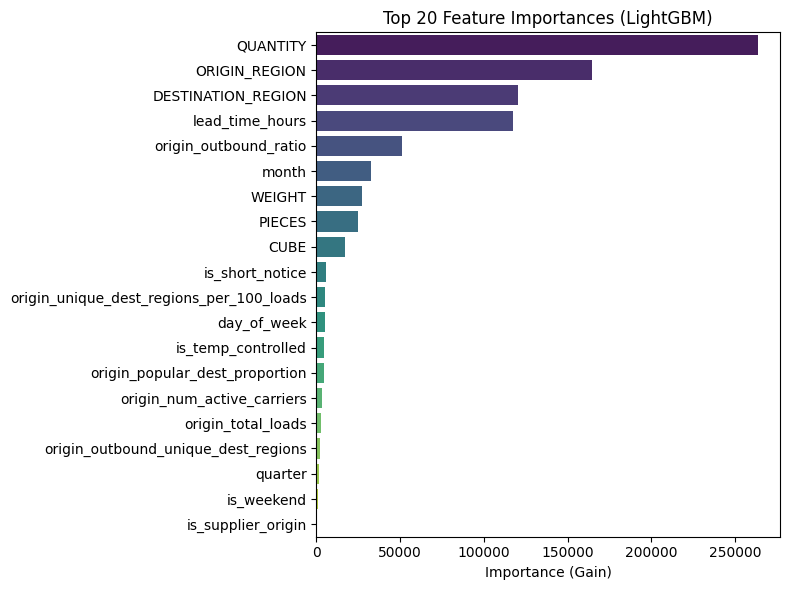


Top 20 lanes by predicted acceptance:
                              LANE_ID  n_loads  predicted_acceptance  actual_acceptance  abs_error
             19416_98_TEMP CONTROLLED       92              0.999719            1.00000   0.000281
             19416_96_TEMP CONTROLLED      126              0.999670            1.00000   0.000330
             13538_84_TEMP CONTROLLED      339              0.999638            1.00000   0.000362
             23065_24_TEMP CONTROLLED      225              0.999630            1.00000   0.000370
             14925_74_TEMP CONTROLLED      994              0.999613            1.00000   0.000387
             19416_27_TEMP CONTROLLED      283              0.999605            1.00000   0.000395
             10570_45_TEMP CONTROLLED      169              0.999601            1.00000   0.000399
             23065_96_TEMP CONTROLLED       96              0.999595            1.00000   0.000405
                     55906_400025_DRY      101              0.999576  

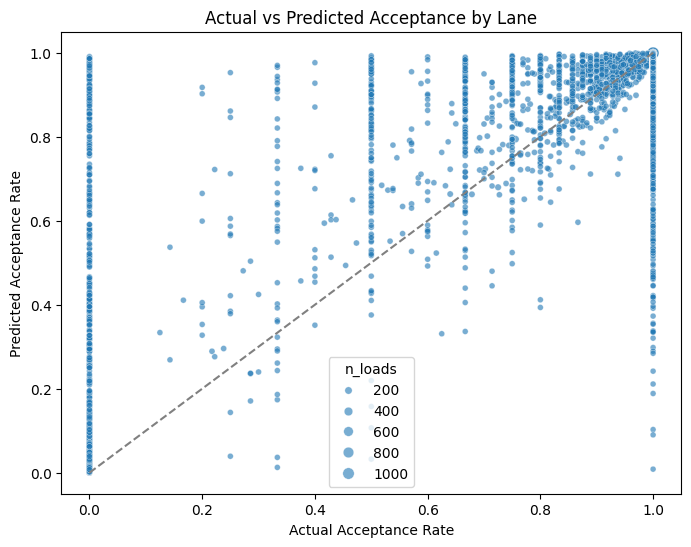

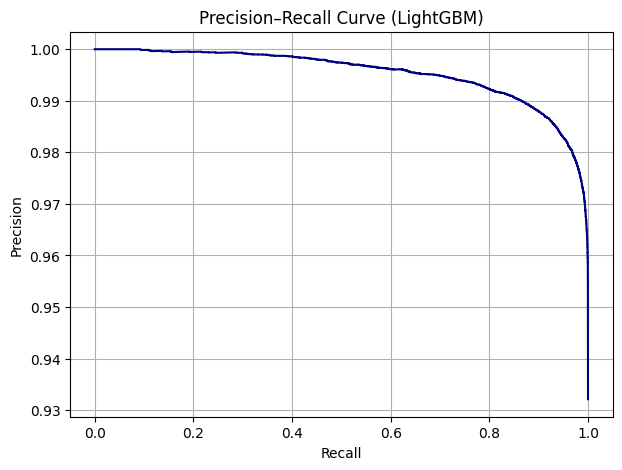

Threshold=0.3  Accuracy=0.962  Recall_Pos=0.999
Threshold=0.4  Accuracy=0.964  Recall_Pos=0.997
Threshold=0.5  Accuracy=0.965  Recall_Pos=0.995
Threshold=0.6  Accuracy=0.965  Recall_Pos=0.992
Threshold=0.7  Accuracy=0.963  Recall_Pos=0.986


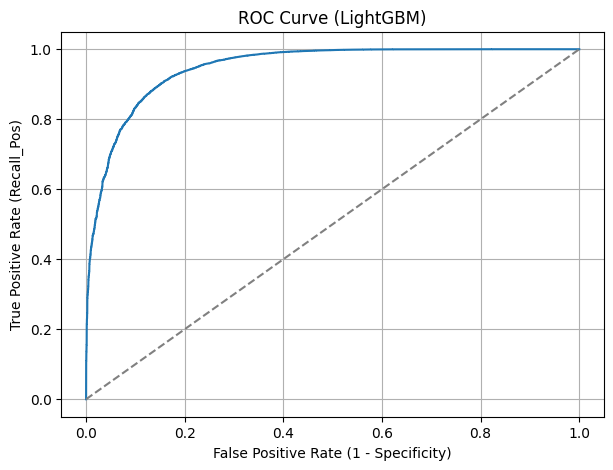


Threshold  Recall_Pos  Recall_Neg(Specificity)
      0.3       0.999                  0.462
      0.4       0.997                  0.504
      0.5       0.995                  0.546
      0.6       0.992                  0.594
      0.7       0.986                  0.647


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# choose LightGBM as the main reference model
df_test_results = df_test_clean.copy()
df_test_results['pred_prob'] = y_test_proba_lgb
df_test_results['pred_class'] = y_test_pred_lgb


# feature importance (LightGBM)
top_feats = feature_importance_lgb.sort_values('Importance', ascending=False).head(20)
plt.figure(figsize=(8,6))
sns.barplot(
    data=top_feats,
    x='Importance',
    y='Feature',
    orient='h',
    palette='viridis'
)
plt.title('Top 20 Feature Importances (LightGBM)')
plt.xlabel('Importance (Gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# lane-level performance summary
lane_stats = (
    df_test_results.groupby('LANE_ID', as_index=False)
    .agg(
        actual_acceptance=('carrier_accepted', 'mean'),
        predicted_acceptance=('pred_prob', 'mean'),
        n_loads=('carrier_accepted', 'size')
    )
)
lane_stats['abs_error'] = (lane_stats['predicted_acceptance'] - lane_stats['actual_acceptance']).abs()

top20 = lane_stats.sort_values('predicted_acceptance', ascending=False).head(20)
bottom20 = lane_stats.sort_values('predicted_acceptance', ascending=True).head(20)

print("\nTop 20 lanes by predicted acceptance:")
print(top20[['LANE_ID', 'n_loads', 'predicted_acceptance', 'actual_acceptance', 'abs_error']].to_string(index=False))

print("\nBottom 20 lanes by predicted acceptance:")
print(bottom20[['LANE_ID', 'n_loads', 'predicted_acceptance', 'actual_acceptance', 'abs_error']].to_string(index=False))

#  Actual vs Predicted scatter
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=lane_stats,
    x='actual_acceptance',
    y='predicted_acceptance',
    size='n_loads',
    alpha=0.6
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('Actual vs Predicted Acceptance by Lane')
plt.xlabel('Actual Acceptance Rate')
plt.ylabel('Predicted Acceptance Rate')
plt.show()

from sklearn.metrics import precision_recall_curve

# Precision-Recall curve for LightGBM
prec, rec, thr = precision_recall_curve(y_test, y_test_proba_lgb)
plt.figure(figsize=(7,5))
plt.plot(rec, prec, color='navy')
plt.title('Precision–Recall Curve (LightGBM)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Quick view of metrics at key thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_test_proba_lgb >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec_pos = confusion_matrix(y_test, y_pred_t)[1,1] / (confusion_matrix(y_test, y_pred_t)[1].sum())
    print(f"Threshold={t:.1f}  Accuracy={acc:.3f}  Recall_Pos={rec_pos:.3f}")

fpr, tpr, roc_thr = roc_curve(y_test, y_test_proba_lgb)
spec = 1 - fpr  # specificity = recall_neg

#negative
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve (LightGBM)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall_Pos)')
plt.grid(True)
plt.show()

# table at key thresholds with recall_neg
def _recalls_at_threshold(t):
    y_pred_t = (y_test_proba_lgb >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    recall_pos = tp / (tp + fn) if (tp + fn) else 0.0
    recall_neg = tn / (tn + fp) if (tn + fp) else 0.0  # specificity
    return recall_pos, recall_neg

print("\nThreshold  Recall_Pos  Recall_Neg(Specificity)")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    r_pos, r_neg = _recalls_at_threshold(t)
    print(f"{t:9.1f}  {r_pos:10.3f}  {r_neg:21.3f}")

**Tuning(CRUCIAL)**

In [ ]:
!pip install scikit-optimize -q

In [ ]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer

param_space = {
    'num_leaves': Integer(20, 127),
    'learning_rate': Real(0.01, 0.20, prior='log-uniform'),
    'max_depth': Integer(3, 10),
    'feature_fraction': Real(0.6, 1.0),
    'bagging_freq': Integer(1, 5),
    'bagging_fraction': Real(0.6, 1.0),
    'lambda_l1': Real(1e-3, 10.0, prior='log-uniform'),
    'lambda_l2': Real(1e-3, 10.0, prior='log-uniform'),
    'min_child_samples': Integer(20, 300),
    'n_estimators': Integer(100, 1500),
}

In [ ]:
import sys
!{sys.executable} -m pip install scikit-optimize -q

from tqdm.auto import tqdm
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import StratifiedKFold
import joblib
from skopt.callbacks import CheckpointSaver
import lightgbm as lgb # Added this import statement

checkpoint_path = '/content/drive/MyDrive/bayes_checkpoint_causal_advanced.pkl'
checkpoint_callback = CheckpointSaver(checkpoint_path, compress=9)

# Initialize LGBMClassifier
lgbm = lgb.LGBMClassifier(
    objective='binary',
    n_jobs=-1,
    random_state=42,
)

# Set Up Cross-Validation
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

bayes_cv = BayesSearchCV(
    estimator=lgbm,
    search_spaces=param_space,
    n_iter=60,
    scoring='neg_log_loss',
    cv=cv,
    refit=True,
    random_state=42,
    n_jobs=1,
    verbose=0
)

total_iter = 60  # Must match the n_iter in BayesSearchCV
pbar = tqdm(total=total_iter, desc="Hyperparameter Tuning")

# Define a simple callback function
# Scikit-optimize passes the 'result' object to this function every step
def on_step(optim_result):
    pbar.update(1)

bayes_cv.fit(X_train_tree, y_train, callback=[checkpoint_callback, on_step])

joblib.dump(bayes_cv, '/content/drive/MyDrive/lightgbm_bayes_search_causal_advanced.joblib')

# Close the bar when done to prevent display glitches
pbar.close()

Hyperparameter Tuning:   0%|          | 0/60 [00:00<?, ?it/s]

In [ ]:
import joblib
import pandas as pd

# The saved object references the 'on_step' callback function from the training step.
# We must define it (even as a dummy) so pickle can find it during loading.
def on_step(optim_result):
    pass

# Load the saved BayesSearchCV object (LightGBM + Bayesian tuning)
bayes_cv_loaded = joblib.load('/content/drive/MyDrive/lightgbm_bayes_search_causal_advanced.joblib')

# Get the best estimator and its parameters
best_estimator = bayes_cv_loaded.best_estimator_
best_params = bayes_cv_loaded.best_params_

print("Best Estimator:")
print(best_estimator)
print("\nBest Parameters found:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

Best Estimator:
LGBMClassifier(bagging_fraction=0.8751394600392653, bagging_freq=1,
               feature_fraction=0.6, lambda_l1=0.001, lambda_l2=0.001,
               learning_rate=0.04774935800729942, max_depth=8, n_estimators=929,
               n_jobs=-1, num_leaves=96, objective='binary', random_state=42)

Best Parameters found:
  bagging_fraction: 0.8751394600392653
  bagging_freq: 1
  feature_fraction: 0.6
  lambda_l1: 0.001
  lambda_l2: 0.001
  learning_rate: 0.04774935800729942
  max_depth: 8
  min_child_samples: 20
  n_estimators: 929
  num_leaves: 96


In [ ]:
from sklearn.metrics import log_loss

y_test_proba_best = bayes_cv_loaded.best_estimator_.predict_proba(X_test_tree)[:, 1]

y_test_pred_best = (y_test_proba_best >= 0.5).astype(int)

# Quickly check the best model's performance on individual predictions before calibration
# Ensure the result is reasonable. This is NOT indicative of how good the model is when
# used in Counterfactual Anaysis
best_auc = roc_auc_score(y_test, y_test_proba_best)
best_log_loss = log_loss(y_test, y_test_proba_best)

print(f"Best Model Test AUC: {best_auc:.4f}")
print(f"Best Model Test Log Loss: {best_log_loss:.4f}")

cm_best = confusion_matrix(y_test, y_test_pred_best)

recall_neg_best = cm_best[0,0] / (cm_best[0,0] + cm_best[0,1])
recall_pos_best = cm_best[1,1] / (cm_best[1,0] + cm_best[1,1])

print("\nConfusion Matrix (Best Model):")
print(f"                  Predicted Negative  Predicted Positive")
print(f"Actual Negative   {cm_best[0,0]:<19} {cm_best[0,1]:<19}")
print(f"Actual Positive   {cm_best[1,0]:<19} {cm_best[1,1]:<19}")
print()
print(f"Recall on negative class: {recall_neg_best:.2%}")
print(f"Recall on positive class: {recall_pos_best:.2%}")

Best Model Test AUC: 0.9561
Best Model Test Log Loss: 0.0986

Confusion Matrix (Best Model):
                  Predicted Negative  Predicted Positive
Actual Negative   2990                2061               
Actual Positive   333                 69036              

Recall on negative class: 59.20%
Recall on positive class: 99.52%


In [ ]:
feature_importance_best = pd.DataFrame({
    'Feature': X_train_tree.columns,
    'Importance': bayes_cv_loaded.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False)

print("TOP FEATURES from the best LightGBM model:")
print(feature_importance_best.head(15).to_string(index=False))

TOP FEATURES from the best LightGBM model:
                                 Feature  Importance
                         lead_time_hours       11987
                                  WEIGHT        8993
                                  PIECES        8812
                           ORIGIN_REGION        8579
                                    CUBE        8487
                      DESTINATION_REGION        7955
                                QUANTITY        7917
                   origin_outbound_ratio        7187
                                   month        4110
          origin_popular_dest_proportion        2247
origin_unique_dest_regions_per_100_loads        2135
                      origin_total_loads        2048
     origin_outbound_unique_dest_regions        1913
                             day_of_week        1762
              origin_num_active_carriers        1672


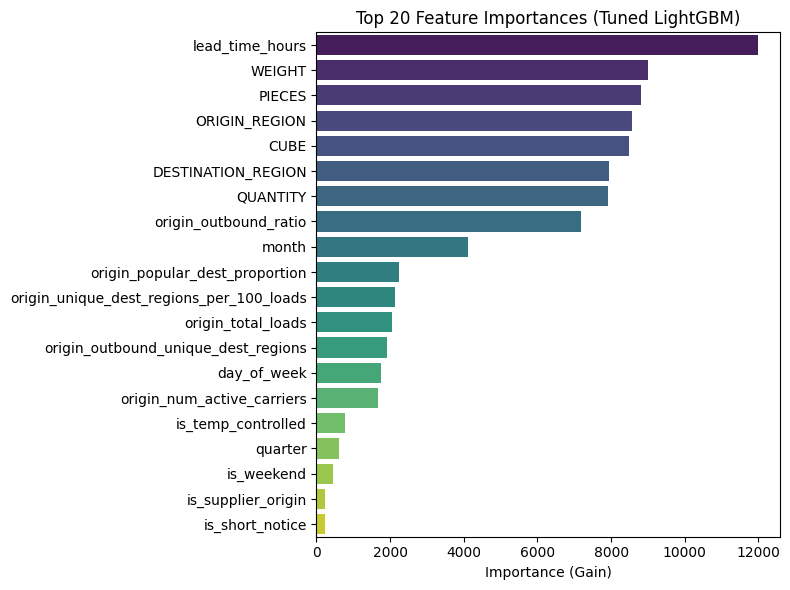


Top 20 lanes by predicted acceptance:
                 LANE_ID  n_loads  predicted_acceptance  actual_acceptance  abs_error
19416_96_TEMP CONTROLLED      126              0.999934                1.0   0.000066
19416_98_TEMP CONTROLLED       92              0.999931                1.0   0.000069
10570_45_TEMP CONTROLLED      169              0.999920                1.0   0.000080
19182_95_TEMP CONTROLLED      199              0.999904                1.0   0.000096
        55906_400025_DRY      101              0.999891                1.0   0.000109
19416_27_TEMP CONTROLLED      283              0.999880                1.0   0.000120
        400025_55906_DRY      114              0.999866                1.0   0.000134
10402_95_TEMP CONTROLLED      110              0.999853                1.0   0.000147
14925_74_TEMP CONTROLLED      994              0.999833                1.0   0.000167
23065_24_TEMP CONTROLLED      225              0.999820                1.0   0.000180
13538_84_TEMP C

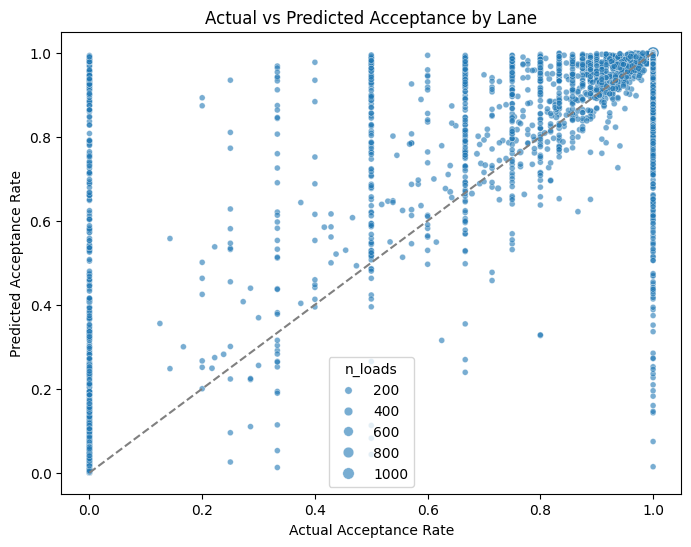

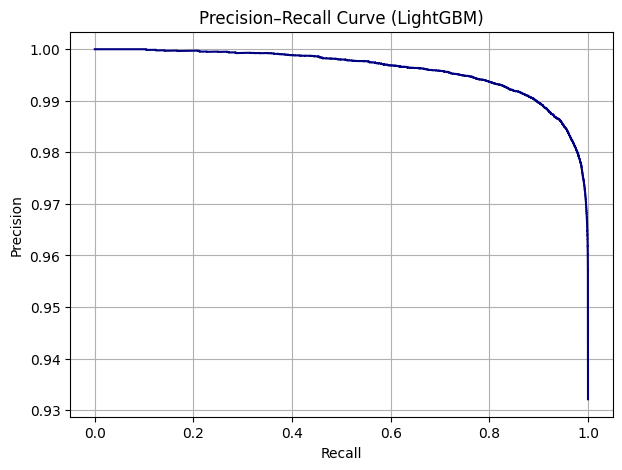

Threshold=0.3  Accuracy=0.966  Recall_Pos=0.998
Threshold=0.4  Accuracy=0.967  Recall_Pos=0.997
Threshold=0.5  Accuracy=0.968  Recall_Pos=0.995
Threshold=0.6  Accuracy=0.968  Recall_Pos=0.992
Threshold=0.7  Accuracy=0.966  Recall_Pos=0.987


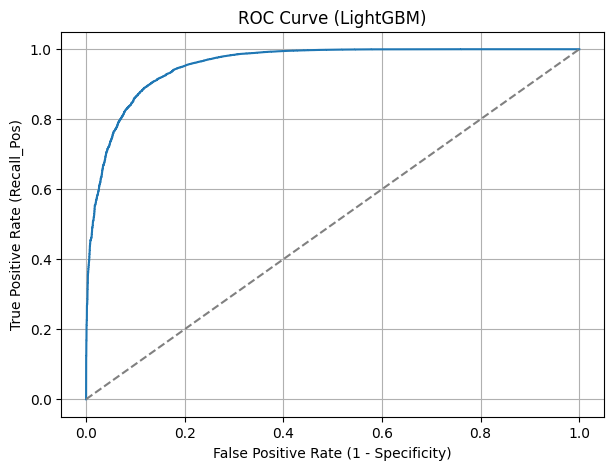


Threshold  Recall_Pos  Recall_Neg(Specificity)
      0.3       0.998                  0.518
      0.4       0.997                  0.555
      0.5       0.995                  0.592
      0.6       0.992                  0.632
      0.7       0.987                  0.682


In [ ]:
# Inspect Learner Performance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# Get Prediction Results
df_test_results = df_test_clean.copy()
df_test_results['pred_prob'] = y_test_proba_best
df_test_results['pred_class'] = y_test_pred_best


# feature importance (Tuned LightGBM)
# Use the already created and sorted feature_importance_best DataFrame
top_feats_for_plot = feature_importance_best.head(20)
plt.figure(figsize=(8,6))
sns.barplot(
    data=top_feats_for_plot,
    x='Importance',
    y='Feature',
    orient='h',
    palette='viridis'
)
plt.title('Top 20 Feature Importances (Tuned LightGBM)')
plt.xlabel('Importance (Gain)')
plt.ylabel('')
plt.tight_layout()
plt.show()

# lane-level performance summary
lane_stats = (
    df_test_results.groupby('LANE_ID', as_index=False)
    .agg(
        actual_acceptance=('carrier_accepted', 'mean'),
        predicted_acceptance=('pred_prob', 'mean'),
        n_loads=('carrier_accepted', 'size')
    )
)
lane_stats['abs_error'] = (lane_stats['predicted_acceptance'] - lane_stats['actual_acceptance']).abs()

top20 = lane_stats.sort_values('predicted_acceptance', ascending=False).head(20)
bottom20 = lane_stats.sort_values('predicted_acceptance', ascending=True).head(20)

print("\nTop 20 lanes by predicted acceptance:")
print(top20[['LANE_ID', 'n_loads', 'predicted_acceptance', 'actual_acceptance', 'abs_error']].to_string(index=False))

print("\nBottom 20 lanes by predicted acceptance:")
print(bottom20[['LANE_ID', 'n_loads', 'predicted_acceptance', 'actual_acceptance', 'abs_error']].to_string(index=False))

#  Actual vs Predicted scatter
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=lane_stats,
    x='actual_acceptance',
    y='predicted_acceptance',
    size='n_loads',
    alpha=0.6
)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('Actual vs Predicted Acceptance by Lane')
plt.xlabel('Actual Acceptance Rate')
plt.ylabel('Predicted Acceptance Rate')
plt.show()

from sklearn.metrics import precision_recall_curve

# Precision-Recall curve for LightGBM
prec, rec, thr = precision_recall_curve(y_test, y_test_proba_best)
plt.figure(figsize=(7,5))
plt.plot(rec, prec, color='navy')
plt.title('Precision–Recall Curve (LightGBM)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Quick view of metrics at key thresholds
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_t = (y_test_proba_best >= t).astype(int)
    acc = accuracy_score(y_test, y_pred_t)
    rec_pos = confusion_matrix(y_test, y_pred_t)[1,1] / (confusion_matrix(y_test, y_pred_t)[1].sum())
    print(f"Threshold={t:.1f}  Accuracy={acc:.3f}  Recall_Pos={rec_pos:.3f}")

fpr, tpr, roc_thr = roc_curve(y_test, y_test_proba_best)
spec = 1 - fpr  # specificity = recall_neg

#negative
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve (LightGBM)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall_Pos)')
plt.grid(True)
plt.show()

# table at key thresholds with recall_neg
def _recalls_at_threshold(t):
    y_pred_t = (y_test_proba_best >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred_t)
    tn, fp, fn, tp = cm.ravel()
    recall_pos = tp / (tp + fn) if (tp + fn) else 0.0
    recall_neg = tn / (tn + fp) if (tn + fp) else 0.0  # specificity
    return recall_pos, recall_neg

print("\nThreshold  Recall_Pos  Recall_Neg(Specificity)")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    r_pos, r_neg = _recalls_at_threshold(t)
    print(f"{t:9.1f}  {r_pos:10.3f}  {r_neg:21.3f}")

In [ ]:
# View the parameter search process (cv_results_)
cv_results_df = pd.DataFrame(bayes_cv_loaded.cv_results_)

print("\nCross-validation results:")
display(cv_results_df.head())


Cross-validation results:


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_bagging_fraction,param_bagging_freq,param_feature_fraction,param_lambda_l1,param_lambda_l2,param_learning_rate,...,param_min_child_samples,param_n_estimators,param_num_leaves,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,25.064397,5.878371,5.760915,1.128041,0.764042,4,0.973147,0.018332,0.479283,0.034576,...,227,526,89,"{'bagging_fraction': 0.7640415835413256, 'bagg...",-0.123773,-0.122665,-0.119260,-0.121899,0.001921,49
1,31.611148,1.251421,9.060914,1.080167,0.934955,5,0.721364,6.381101,2.860959,0.012052,...,119,990,122,"{'bagging_fraction': 0.9349553422213137, 'bagg...",-0.138995,-0.137158,-0.134440,-0.136865,0.001871,56
2,26.504735,0.227449,8.167966,0.945866,0.777933,5,0.641944,0.054117,0.005647,0.038925,...,230,880,124,"{'bagging_fraction': 0.7779330049204607, 'bagg...",-0.126463,-0.125114,-0.121952,-0.124510,0.001891,51
3,77.363512,2.196066,24.854131,0.174330,0.924958,2,0.839219,1.625770,0.123654,0.013310,...,264,1377,61,"{'bagging_fraction': 0.9249583953429453, 'bagg...",-0.113233,-0.111778,-0.109093,-0.111368,0.001715,28
4,29.451080,0.118776,9.615439,0.852709,0.919821,3,0.810648,0.729211,4.124851,0.085680,...,202,594,91,"{'bagging_fraction': 0.9198213766428692, 'bagg...",-0.109068,-0.108466,-0.105400,-0.107645,0.001606,17


**Build Counterfactual Analysis Dataset**

In [ ]:
# Create a copy with selected features
selected_features = tree_continuous_features + tree_binary_features + tree_categorical_features
df_counterfactual = df[selected_features].copy()

# Get the target destination region from the first row
target_region = df_counterfactual['DESTINATION_REGION'].iloc[0]
print(f"Setting all DESTINATION_REGION to: {target_region}")

# Apply counterfactual change: set all rows to have this region
df_counterfactual['DESTINATION_REGION'] = target_region

# Verify the change
display(df_counterfactual.head())
print("\nValue counts for DESTINATION_REGION in counterfactual df:")
print(df_counterfactual['DESTINATION_REGION'].value_counts())

Setting all DESTINATION_REGION to: MO_STL


,CUBE,WEIGHT,PIECES,QUANTITY,origin_total_loads,origin_outbound_ratio,origin_outbound_unique_dest_regions,origin_unique_dest_regions_per_100_loads,origin_num_active_carriers,origin_popular_dest_proportion,...,is_weekend,is_short_notice,is_temp_controlled,is_supplier_origin,is_rare_origin,month,day_of_week,quarter,ORIGIN_REGION,DESTINATION_REGION
0,1756,41040,1080,921.0,2860.0,1369.0,41.0,0.014336,49.0,54.055944,...,1,0,1,1,0.0,6,5,2,WI_GRE,MO_STL
1,80,39600,1100,156.0,4657.0,1400.0,44.0,0.009448,41.0,22.095770,...,0,0,1,1,0.0,6,0,2,AR_FAY,MO_STL
2,455,30114,630,1040.0,9471.0,1206.0,26.0,0.002745,51.0,74.733397,...,0,0,1,1,0.0,6,2,2,CA_STK,MO_STL
3,3675,17712,864,85.0,7325.0,400.0,51.0,0.006962,73.0,31.440273,...,0,0,0,1,0.0,5,4,2,NC_CHA,MO_STL
4,166,38467,1422,208.0,8263.0,708.0,41.0,0.004962,66.0,63.669369,...,0,0,0,1,0.0,6,3,2,CA_ONT,MO_STL



Value counts for DESTINATION_REGION in counterfactual df:
DESTINATION_REGION
MO_STL    384873
Name: count, dtype: int64


Quickly try simulation on one market to check things work

In [ ]:
import scipy.stats as stats
import numpy as np

# Get the best model
best_model = bayes_cv_loaded.best_estimator_

# Ensure categorical columns match the original model's expectation
# Assigning a single value (e.g. 'MO_STL') changes the column to object/string or resets categories.
# We must restore the original categorical dtype from 'df' so LightGBM recognizes it.
for col in tree_categorical_features:
    if col in df_counterfactual.columns:
        df_counterfactual[col] = df_counterfactual[col].astype(df[col].dtype)

# Predict probabilities on the counterfactual dataset
# Note: LightGBM handles NaNs natively, so we pass the dataframe directly
print("Predicting probabilities on counterfactual dataset...")
counterfactual_probs = best_model.predict_proba(df_counterfactual)[:, 1]

# Calculate mean
mean_prob = np.mean(counterfactual_probs)

# Calculate standard error of the mean (SEM)
n = len(counterfactual_probs)
std_dev = np.std(counterfactual_probs, ddof=1)
sem = std_dev / np.sqrt(n)

# Calculate 95% Confidence Interval
# Using z-score of 1.96 for 95% CI (large sample size)
ci_lower = mean_prob - 1.96 * sem
ci_upper = mean_prob + 1.96 * sem

print(f"\nCounterfactual Analysis Results (Target Region: {target_region}):")
print(f"Number of records: {n:,}")
print(f"Mean Predicted Acceptance Probability: {mean_prob:.4f}")
print(f"95% Confidence Interval: [{ci_lower:.4f}, {ci_upper:.4f}]")

Predicting probabilities on counterfactual dataset...

Counterfactual Analysis Results (Target Region: MO_STL):
Number of records: 384,873
Mean Predicted Acceptance Probability: 0.9149
95% Confidence Interval: [0.9142, 0.9157]


**Calibrate learner model**

In [ ]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Split the existing Test set into Calibration (50%) and Final Test (50%)
# We use a separate set for calibration to avoid overfitting the calibration map
X_calib, X_test_final, y_calib, y_test_final = train_test_split(
    X_test_tree, y_test, test_size=0.5, random_state=42, stratify=y_test
)

print(f"Calibration set: {len(X_calib):,} records")
print(f"Final Test set:  {len(X_test_final):,} records")

Calibration set: 37,210 records
Final Test set:  37,210 records


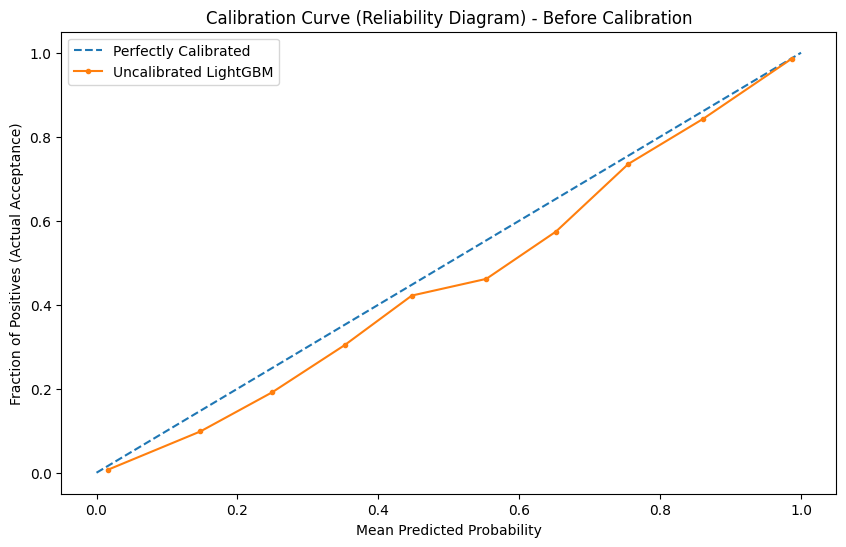

Uncalibrated Brier Score: 0.0259
Uncalibrated Log Loss:    0.0989


In [ ]:
# 2. Visualize the current calibration (Uncalibrated)
best_model = bayes_cv_loaded.best_estimator_
prob_uncalibrated = best_model.predict_proba(X_test_final)[:, 1]

fop_uncalibrated, mpv_uncalibrated = calibration_curve(y_test_final, prob_uncalibrated, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(mpv_uncalibrated, fop_uncalibrated, marker='.', label='Uncalibrated LightGBM')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Acceptance)')
plt.title('Calibration Curve (Reliability Diagram) - Before Calibration')
plt.legend()
plt.show()

print(f"Uncalibrated Brier Score: {brier_score_loss(y_test_final, prob_uncalibrated):.4f}")
print(f"Uncalibrated Log Loss:    {log_loss(y_test_final, prob_uncalibrated):.4f}")

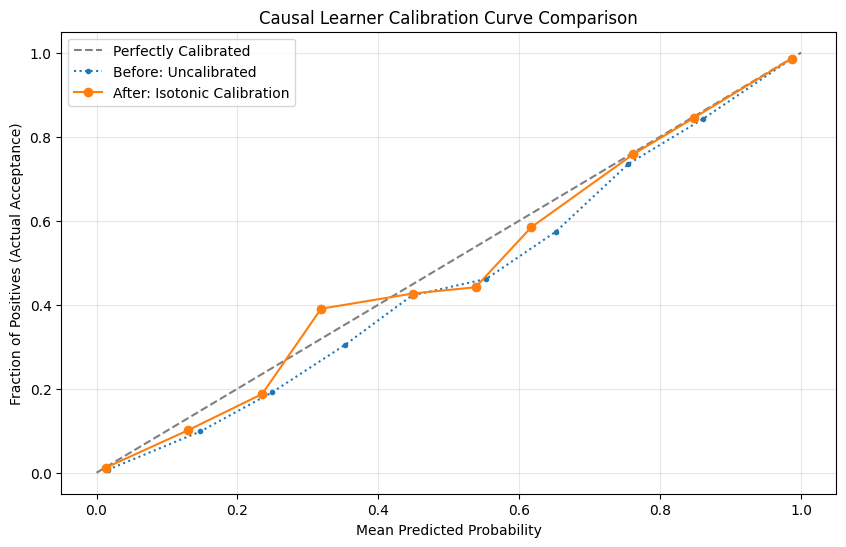

METRICS COMPARISON:
Brier Score (Lower is better): 0.02586 -> 0.02582
Log Loss    (Lower is better): 0.09887 -> 0.10053


In [ ]:
# 3. Calibrate using Isotonic Regression
# cv='prefit' assumes the base estimator is already fitted.
calibrated_clf = CalibratedClassifierCV(best_model, method='isotonic', cv='prefit')

# Fit the calibrator on the calibration set
calibrated_clf.fit(X_calib, y_calib)

# Predict on the final test set
prob_calibrated = calibrated_clf.predict_proba(X_test_final)[:, 1]

# 4. Compare Results
fop_calibrated, mpv_calibrated = calibration_curve(y_test_final, prob_calibrated, n_bins=10)

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.plot(mpv_uncalibrated, fop_uncalibrated, marker='.', linestyle=':', label='Before: Uncalibrated')
plt.plot(mpv_calibrated, fop_calibrated, marker='o', label='After: Isotonic Calibration')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives (Actual Acceptance)')
plt.title('Causal Learner Calibration Curve Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("METRICS COMPARISON:")
print(f"Brier Score (Lower is better): {brier_score_loss(y_test_final, prob_uncalibrated):.5f} -> {brier_score_loss(y_test_final, prob_calibrated):.5f}")
print(f"Log Loss    (Lower is better): {log_loss(y_test_final, prob_uncalibrated):.5f} -> {log_loss(y_test_final, prob_calibrated):.5f}")

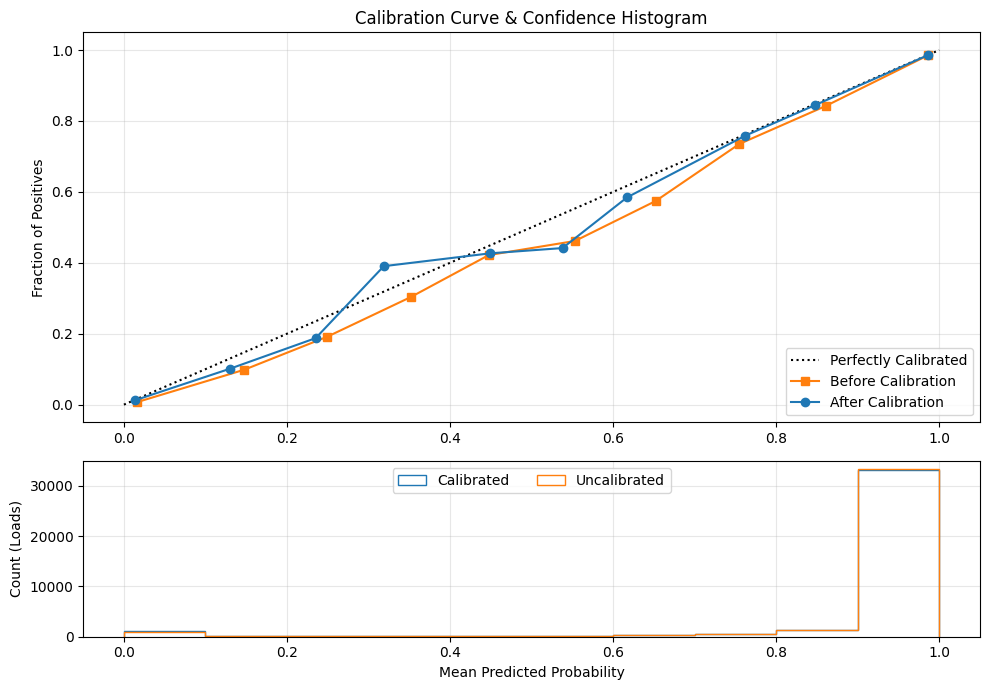

In [ ]:
# Enhanced Calibration Plot with Sample Size Distribution
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

plt.figure(figsize=(10, 7))

# Create two subplots sharing the x-axis
ax1 = plt.subplot2grid((3, 1), (0, 0), rowspan=2)
ax2 = plt.subplot2grid((3, 1), (2, 0))

# 1. Plot Calibration Curve (Top Plot)
ax1.plot([0, 1], [0, 1], "k:", label="Perfectly Calibrated")

# Calculate curve for Uncalibrated
fop, mpv = calibration_curve(y_test_final, prob_uncalibrated, n_bins=10)
ax1.plot(mpv, fop, "s-", label="Before Calibration", color='tab:orange')

# Calculate curve for Calibrated
fop_cal, mpv_cal = calibration_curve(y_test_final, prob_calibrated, n_bins=10)
ax1.plot(mpv_cal, fop_cal, "o-", label="After Calibration", color='tab:blue')

ax1.set_ylabel("Fraction of Positives")
ax1.set_title("Calibration Curve & Confidence Histogram")
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# 2. Plot Histogram of Predicted Probabilities (Bottom Plot)
# This shows WHERE the data actually is
ax2.hist(prob_calibrated, range=(0, 1), bins=10, label="Calibrated",
         histtype="step", lw=2, color='tab:blue')
ax2.hist(prob_uncalibrated, range=(0, 1), bins=10, label="Uncalibrated",
         histtype="step", lw=2, ls='--', color='tab:orange')

ax2.set_xlabel("Mean Predicted Probability")
ax2.set_ylabel("Count (Loads)")
ax2.legend(loc="upper center", ncol=2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Full Simulatioin (Crucial)**

In [ ]:
from tqdm.auto import tqdm

# 1. Identify valid regions (> 20 loads)
region_counts = df['DESTINATION_REGION'].value_counts()
valid_regions = region_counts[region_counts > 20].index.tolist()

print(f"Analyzing {len(valid_regions)} unique regions with > 20 loads...")

results = []

# Use the existing df_counterfactual container to avoid overhead
# (It already has the correct columns selected)

for region in tqdm(valid_regions, desc="Processing Regions"):
    # A. Apply Counterfactual: Set destination to current region
    df_counterfactual['DESTINATION_REGION'] = region

    # B. Fix Types: Ensure categorical columns match the original training data
    # (Crucial step for LightGBM to avoid "categorical_feature do not match" error)
    for col in tree_categorical_features:
        df_counterfactual[col] = df_counterfactual[col].astype(df[col].dtype)

    # C. Predict using Calibrated Model
    # We use the calibrated classifier for accurate probability estimation
    probs = calibrated_clf.predict_proba(df_counterfactual)[:, 1]

    # D. Calculate Statistics
    mean_prob = np.mean(probs)
    std_dev = np.std(probs, ddof=1)
    n_samples = len(probs)
    sem = std_dev / np.sqrt(n_samples)

    # 95% CI
    ci_lower = mean_prob - 1.96 * sem
    ci_upper = mean_prob + 1.96 * sem

    results.append({
        'Region': region,
        'Predicted_Acceptance': mean_prob,
        'CI_Lower': ci_lower,
        'CI_Upper': ci_upper,
        'Original_Load_Count': region_counts[region]
    })

# Convert to DataFrame and Sort
results_df = pd.DataFrame(results).sort_values('Predicted_Acceptance', ascending=False)

# Display top 20 best regions
print("\nTop 20 Regions by Predicted Acceptance (Counterfactual):")
display(results_df.head(20))

# Display bottom 20 regions
print("\nBottom 20 Regions by Predicted Acceptance (Counterfactual):")
display(results_df.tail(20))

Analyzing 62 unique regions with > 20 loads...


Processing Regions:   0%|          | 0/62 [00:00<?, ?it/s]


Top 20 Regions by Predicted Acceptance (Counterfactual):


,Region,Predicted_Acceptance,CI_Lower,CI_Upper,Original_Load_Count
58,FL_JAX,0.935784,0.935088,0.936479,156
55,ON_TOR,0.931503,0.930797,0.932209,305
27,MN_MIN,0.931053,0.930408,0.931698,5112
34,TX_ANT,0.930263,0.929599,0.930927,4278
30,IA_DES,0.929906,0.929231,0.930582,4600
61,AB_CAL,0.929445,0.928772,0.930118,81
54,WI_MAD,0.929409,0.928696,0.930121,394
50,TN_MEM,0.928957,0.928246,0.929668,1019
44,OK_OKC,0.928202,0.927485,0.928919,1426
46,GA_SAV,0.925622,0.924902,0.926342,1330



Bottom 20 Regions by Predicted Acceptance (Counterfactual):


,Region,Predicted_Acceptance,CI_Lower,CI_Upper,Original_Load_Count
37,GA_MAC,0.902713,0.901967,0.903458,3698
26,OR_POR,0.901080,0.900343,0.901817,5591
49,NV_VEG,0.900334,0.899604,0.901064,1057
1,CA_ONT,0.900313,0.899544,0.901082,20121
7,TX_HOU,0.899720,0.898964,0.900475,13498
22,TN_NAS,0.899312,0.898567,0.900056,7756
35,NY_ELM,0.898948,0.898191,0.899706,3787
19,NC_CHA,0.897376,0.896666,0.898086,7976
8,CA_STK,0.896963,0.896215,0.897711,13004
5,FL_LAK,0.896390,0.895641,0.897139,15166


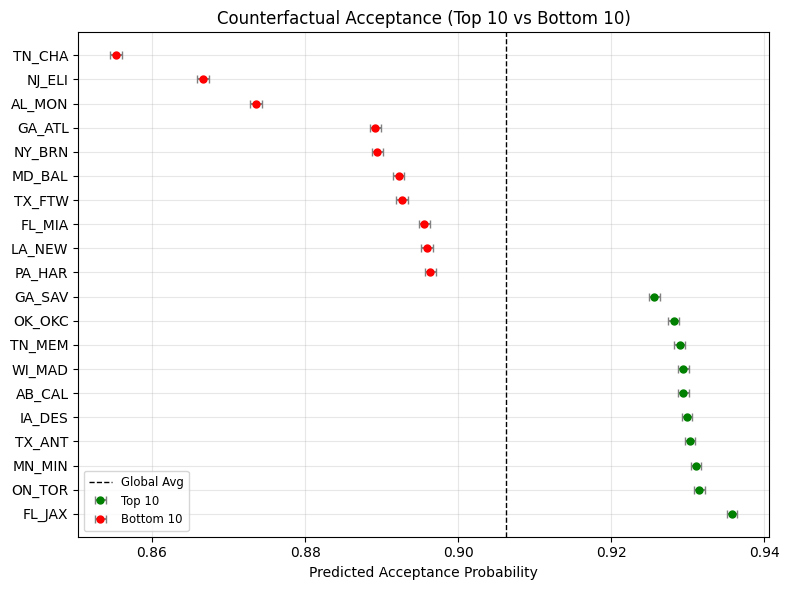

In [ ]:
# Optional: Visualize the top and bottom regions
plt.figure(figsize=(8, 6))

# Get top 10 and bottom 10
top_10 = results_df.head(10)
bottom_10 = results_df.tail(10)

# Plot Top 10 (Green)
plt.errorbar(
    x=top_10['Predicted_Acceptance'],
    y=top_10['Region'],
    xerr=(top_10['Predicted_Acceptance'] - top_10['CI_Lower']),
    fmt='o',
    color='green',
    ecolor='gray',
    capsize=3,
    markersize=5,
    label='Top 10'
)

# Plot Bottom 10 (Red)
plt.errorbar(
    x=bottom_10['Predicted_Acceptance'],
    y=bottom_10['Region'],
    xerr=(bottom_10['Predicted_Acceptance'] - bottom_10['CI_Lower']),
    fmt='o',
    color='red',
    ecolor='gray',
    capsize=3,
    markersize=5,
    label='Bottom 10'
)

plt.axvline(df['carrier_accepted'].mean(), color='black', linestyle='--', linewidth=1, label='Global Avg')
plt.title('Counterfactual Acceptance (Top 10 vs Bottom 10)')
plt.xlabel('Predicted Acceptance Probability')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower left', fontsize='small')
plt.tight_layout()
plt.show()